<a href="https://colab.research.google.com/github/niyathinithiyanandan-eng/niyathinithiyananan-eng/blob/main/intern_proj.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

In [2]:
import pandas as pd #Generate Sample Inventory Dataset
import numpy as np

np.random.seed(42)

dates = pd.date_range(start='2024-01-01', periods=365)

products = ['Laptop', 'Mouse', 'Keyboard', 'Monitor', 'Printer']

data = []

for date in dates:
    for product in products:

        stock = np.random.randint(50, 200)

        units_sold = np.random.randint(5, 50)

        price = np.random.randint(500, 5000)

        data.append([date, product, stock, units_sold, price])

df = pd.DataFrame(data, columns=[
    'date',
    'product',
    'stock',
    'units_sold',
    'price'
])

print(df.head())

df.to_csv('inventory_data.csv', index=False)

        date   product  stock  units_sold  price
0 2024-01-01    Laptop    152          33   4272
1 2024-01-01     Mouse     70          43    966
2 2024-01-01  Keyboard    124          15   3944
3 2024-01-01   Monitor    149          44    630
4 2024-01-01   Printer    199           6   2891


In [3]:
print(df.info()) #basic data analysis

print(df.describe())

print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1825 entries, 0 to 1824
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        1825 non-null   datetime64[ns]
 1   product     1825 non-null   object        
 2   stock       1825 non-null   int64         
 3   units_sold  1825 non-null   int64         
 4   price       1825 non-null   int64         
dtypes: datetime64[ns](1), int64(3), object(1)
memory usage: 71.4+ KB
None
                      date        stock   units_sold        price
count                 1825  1825.000000  1825.000000  1825.000000
mean   2024-07-01 00:00:00   125.612603    27.231233  2752.277808
min    2024-01-01 00:00:00    50.000000     5.000000   501.000000
25%    2024-04-01 00:00:00    88.000000    16.000000  1620.000000
50%    2024-07-01 00:00:00   127.000000    27.000000  2726.000000
75%    2024-09-30 00:00:00   163.000000    38.000000  3869.000000
max    2024-12-30 00:

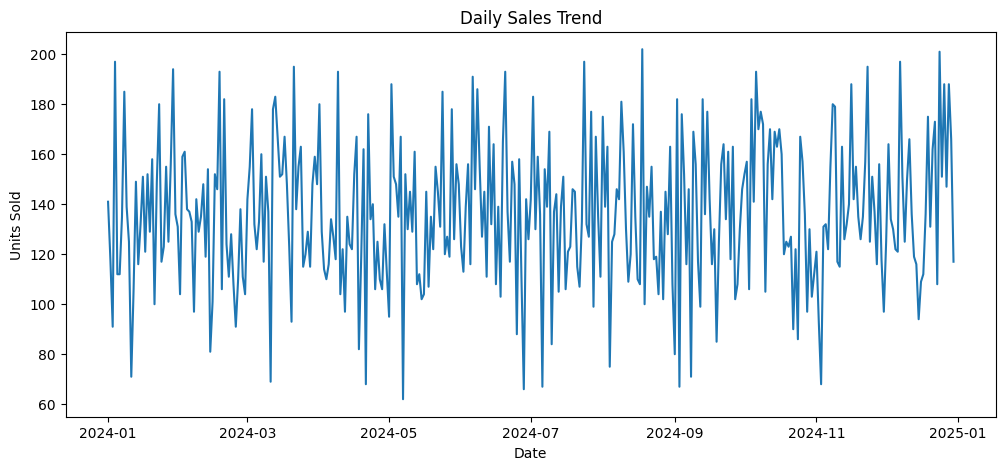

In [4]:
daily_sales = df.groupby('date')['units_sold'].sum() #Visualization Dashboard

plt.figure(figsize=(12,5))

plt.plot(daily_sales)

plt.title('Daily Sales Trend')

plt.xlabel('Date')

plt.ylabel('Units Sold')

plt.show()

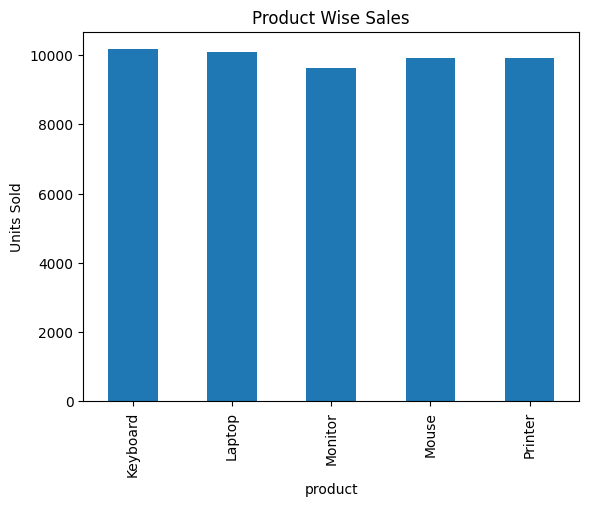

In [5]:
product_sales = df.groupby('product')['units_sold'].sum() #Inventory Analysis

product_sales.plot(kind='bar')

plt.title('Product Wise Sales')

plt.ylabel('Units Sold')

plt.show()

In [6]:
import sqlite3

conn = sqlite3.connect('inventory.db')

df.to_sql('inventory', conn, if_exists='replace', index=False)

1825

In [7]:
query = """
SELECT product,
SUM(units_sold) as total_sales
FROM inventory
GROUP BY product
"""
result = pd.read_sql(query, conn)

print(result)

    product  total_sales
0  Keyboard        10163
1    Laptop        10072
2   Monitor         9633
3     Mouse         9922
4   Printer         9907


In [8]:
query2 = """
SELECT product,
SUM(units_sold * price) as revenue
FROM inventory
GROUP BY product
ORDER BY revenue DESC
"""

result2 = pd.read_sql(query2, conn)

print(result2)

    product   revenue
0     Mouse  28419731
1  Keyboard  28297968
2    Laptop  27495224
3   Printer  27206297
4   Monitor  25640936


In [9]:
df['date'] = pd.to_datetime(df['date']) #ml part feature engineering

df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['weekday'] = df['date'].dt.weekday

In [10]:
df['product'] = df['product'].astype('category').cat.codes #convert product name into num

In [11]:
X = df[['product', 'stock', 'price', #define feature and target
        'year', 'month', 'day', 'weekday']]

y = df['units_sold']

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
) #train test split

In [13]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train) #train random forest model

RandomForestRegressor(random_state=42)

In [14]:
predictions = model.predict(X_test)

print(predictions[:10])

[30.89 34.9  24.56 24.31 31.76 22.27 26.21 27.71 26.41 26.04]


In [15]:
mae = mean_absolute_error(y_test, predictions)

print("Mean Absolute Error:", mae)#model accuracy

Mean Absolute Error: 11.67854794520548


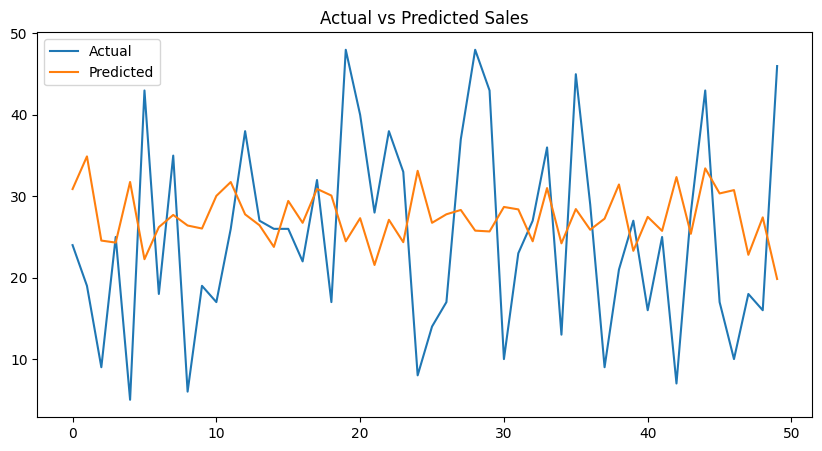

In [16]:
plt.figure(figsize=(10,5))

plt.plot(y_test.values[:50], label='Actual')

plt.plot(predictions[:50], label='Predicted')

plt.legend()

plt.title('Actual vs Predicted Sales')

plt.show() #prediction visualization

In [17]:
df.to_excel('inventory_dashboard.xlsx', index=False)